# LDA Comparison: Scratch vs sklearn

This notebook compares the custom `LDA` implementation against `sklearn.discriminant_analysis.LinearDiscriminantAnalysis` using the `solver='eigen'` setting.

Goal: verify the results are numerically close (allowing small floating-point differences and sign ambiguity in eigenvectors).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as SkLDA

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == 'comparison' else Path.cwd().resolve()
if str(PROJECT_ROOT / 'tiaan_lda') not in sys.path:
    sys.path.append(str(PROJECT_ROOT / 'tiaan_lda'))

from lda import LDA
from lda_utils import compute_scatter_matrices, compute_normalized_scatter_matrices


In [2]:
# Load data (Iris)
df = pd.read_csv(PROJECT_ROOT / 'data' / 'iris.csv')
X_samples_features = df.drop('variety', axis=1).to_numpy()
y = df['variety'].to_numpy()

# features on rows, observations on columns
X_features_samples = X_samples_features.T

n_classes = np.unique(y).size
n_components = min(X_features_samples.shape[0], n_classes - 1)

print('X (samples, features):', X_samples_features.shape)
print('X (features, samples):', X_features_samples.shape)
print('y shape:', y.shape)
print('n_classes:', n_classes, '| n_components:', n_components)

X (samples, features): (150, 4)
X (features, samples): (4, 150)
y shape: (150,)
n_classes: 3 | n_components: 2


In [3]:
# Fit scratch LDA
scratch = LDA(n_components=n_components)
Z_scratch = scratch.fit_transform(X_features_samples, y)     # (n_components, n_samples)

# Fit sklearn LDA (eigen solver as requested)
sk = SkLDA(n_components=n_components, solver='eigen')
Z_sk = sk.fit_transform(X_samples_features, y)               # (n_samples, n_components)

# Put sklearn projection in same orientation as scratch: (n_components, n_samples)
Z_sk = Z_sk.T

print('Z_scratch shape:', Z_scratch.shape)
print('Z_sk shape:', Z_sk.shape)

Z_scratch shape: (2, 150)
Z_sk shape: (2, 150)


In [4]:
# Align signs per component (eigenvectors are sign-ambiguous)
def align_component_signs(reference, candidate):
    aligned = candidate.copy()
    for i in range(reference.shape[0]):
        if np.dot(reference[i], aligned[i]) < 0:
            aligned[i] *= -1
    return aligned

Z_sk_aligned = align_component_signs(Z_scratch, Z_sk)

abs_diff = np.abs(Z_scratch - Z_sk_aligned)
print('Projection comparison (after sign alignment):')
print('  max abs diff :', abs_diff.max())
print('  mean abs diff:', abs_diff.mean())

Projection comparison (after sign alignment):
  max abs diff : 10.634616809194203
  mean abs diff: 6.071422208263663


In [5]:
# Explained variance ratio comparison
evr_scratch = np.asarray(scratch.explained_variance_ratio)
evr_sk = np.asarray(sk.explained_variance_ratio_)

print('explained_variance_ratio (scratch):', evr_scratch)
print('explained_variance_ratio (sklearn):', evr_sk)
print('max abs diff:', np.max(np.abs(evr_scratch - evr_sk)))

explained_variance_ratio (scratch): [0.9912126 0.0087874]
explained_variance_ratio (sklearn): [0.9912126 0.0087874]
max abs diff: 2.220446049250313e-16


In [6]:
# Class means comparison
# scratch.class_means shape: (n_features, n_classes)
# sklearn.means_ shape:      (n_classes, n_features)
means_scratch = scratch.class_means.T
means_sk = sk.means_

means_diff = np.abs(means_scratch - means_sk)
print('Class means comparison:')
print('  max abs diff :', means_diff.max())
print('  mean abs diff:', means_diff.mean())

Class means comparison:
  max abs diff : 0.0
  mean abs diff: 0.0


In [7]:
# Scatter matrix consistency checks (unnormalized and normalized)
S_w_scratch, S_b_scratch = compute_scatter_matrices(X_features_samples, y)

# sklearn covariance-like within-class matrix
S_w_sk_cov = sk.covariance_

# Compare unnormalized scatter first
n_samples = X_samples_features.shape[0]
n_classes = np.unique(y).size
S_w_scratch_from_cov = S_w_sk_cov * (n_samples - n_classes)

global_mean_sk = X_samples_features.mean(axis=0)
S_b_sk = np.zeros_like(S_w_sk_cov)
classes, counts = np.unique(y, return_counts=True)
for i, cls in enumerate(classes):
    dm = sk.means_[i] - global_mean_sk
    S_b_sk += counts[i] * np.outer(dm, dm)

print('Unnormalized comparison:')
print('  S_w max abs diff :', np.max(np.abs(S_w_scratch - S_w_scratch_from_cov)))
print('  S_w mean abs diff:', np.mean(np.abs(S_w_scratch - S_w_scratch_from_cov)))
print('  S_b max abs diff :', np.max(np.abs(S_b_scratch - S_b_sk)))
print('  S_b mean abs diff:', np.mean(np.abs(S_b_scratch - S_b_sk)))

# Compare normalized versions of S_w against sklearn.covariance_
modes = ['pooled_unbiased', 'pooled_mle', 'weighted_class_cov']
print()
print('Normalized S_w vs sklearn.covariance_:')
for mode in modes:
    S_w_norm, S_b_norm = compute_normalized_scatter_matrices(
        X_features_samples, y, mode=mode
    )
    diff = np.abs(S_w_norm - S_w_sk_cov)
    print(f'  mode={mode:>18} | max abs diff={diff.max():.12f} | mean abs diff={diff.mean():.12f}')


Unnormalized comparison:
  S_w max abs diff : 0.779124000000003
  S_w mean abs diff: 0.2693732500000004
  S_b max abs diff : 0.0
  S_b mean abs diff: 0.0

Normalized S_w vs sklearn.covariance_:
  mode=   pooled_unbiased | max abs diff=0.005300163265 | mean abs diff=0.001832471088
  mode=        pooled_mle | max abs diff=0.000000000000 | mean abs diff=0.000000000000
  mode=weighted_class_cov | max abs diff=0.005300163265 | mean abs diff=0.001832471088


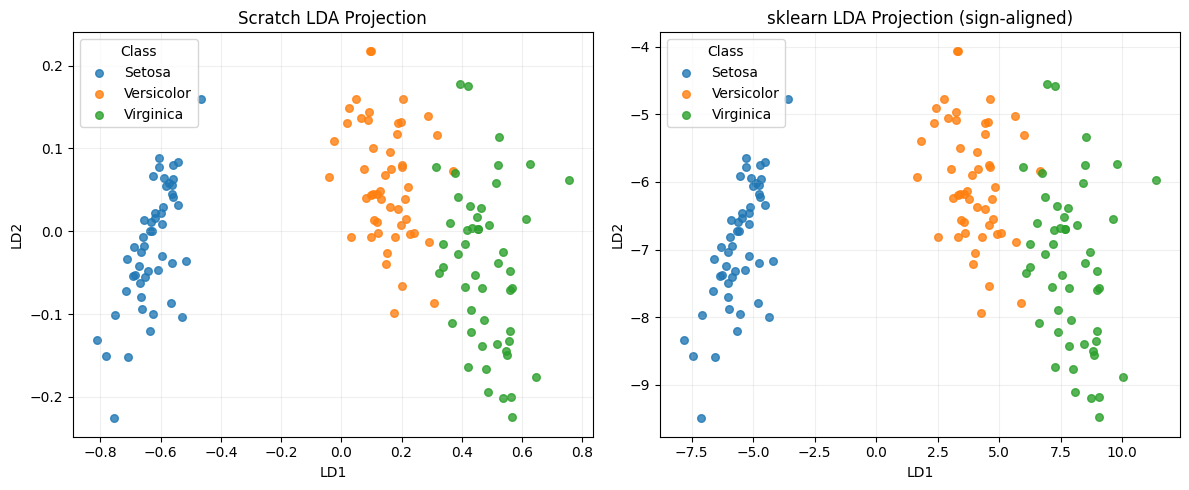

In [8]:
# Visual compare of projected space
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = np.unique(y)
for c in labels:
    mask = (y == c)
    axes[0].scatter(Z_scratch[0, mask], Z_scratch[1, mask], label=str(c), alpha=0.8, s=30)
    axes[1].scatter(Z_sk_aligned[0, mask], Z_sk_aligned[1, mask], label=str(c), alpha=0.8, s=30)

axes[0].set_title('Scratch LDA Projection')
axes[1].set_title('sklearn LDA Projection (sign-aligned)')
for ax in axes:
    ax.set_xlabel('LD1')
    ax.set_ylabel('LD2')
    ax.grid(alpha=0.2)
    ax.legend(title='Class')

plt.tight_layout()
plt.show()

## Notes
- Small numeric differences are expected due to implementation details and floating-point arithmetic.
- Projection vectors are only defined up to sign, so sign alignment is required before direct comparison.
- If these metrics are all small, your scratch implementation is behaving like sklearn's eigen-solver LDA.